# Embeddings and Backpropagation Project

Vocab: cat, dog, sleeps, runs, teacher, teaches

Starting embeddings:
- cat = (1, 1)
- dog = (1, 0.5)
- runs = (-1, 1)
- sleeps = (0.1, -0.1)
- teacher = (1, -0.9)
- teaches = (-0.5, -0.5)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

embeddings = {
    'cat':     np.array([ 1.0,  1.0]),
    'dog':     np.array([ 1.0,  0.5]),
    'runs':    np.array([-1.0,  1.0]),
    'sleeps':  np.array([ 0.1, -0.1]),
    'teacher': np.array([ 1.0, -0.9]),
    'teaches': np.array([-0.5, -0.5]),
}

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def cos_sim(u, v):
    return float(np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v) + 1e-12))

## Q1

### (a) Plot

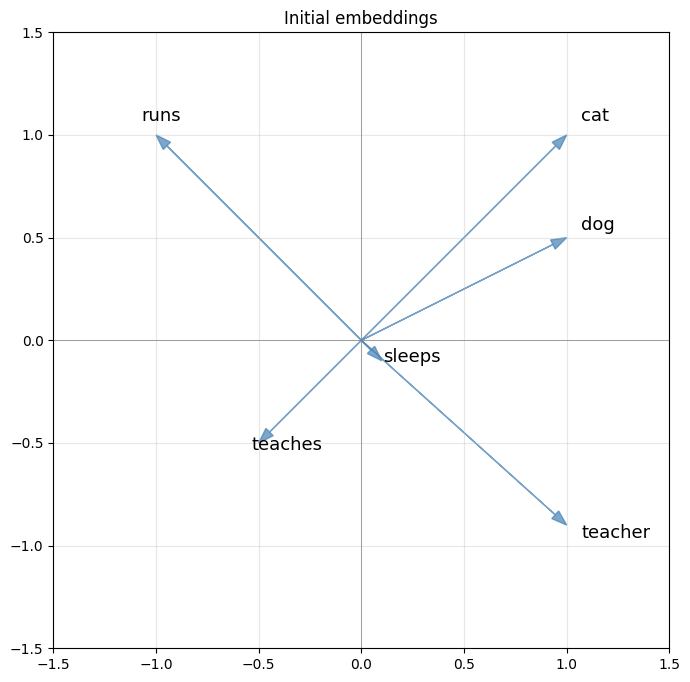

In [2]:
fig, ax = plt.subplots(figsize=(8, 8))
for w, v in embeddings.items():
    ax.arrow(0, 0, v[0], v[1], head_width=0.05, length_includes_head=True,
             color='steelblue', alpha=0.7)
    ax.text(v[0]*1.07, v[1]*1.07, w, fontsize=13)
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.set_title('Initial embeddings')
ax.grid(alpha=0.3)
plt.show()

In [3]:
# check initial cosine sims to see what starts related by accident
items = list(embeddings.items())
for i, (n1, v1) in enumerate(items):
    for n2, v2 in items[i+1:]:
        print(f'  {n1:8s} ~ {n2:8s}: {cos_sim(v1, v2):+.3f}')

  cat      ~ dog     : +0.949
  cat      ~ runs    : +0.000
  cat      ~ sleeps  : +0.000
  cat      ~ teacher : +0.053
  cat      ~ teaches : -1.000
  dog      ~ runs    : -0.316
  dog      ~ sleeps  : +0.316
  dog      ~ teacher : +0.366
  dog      ~ teaches : -0.949
  runs     ~ sleeps  : -1.000
  runs     ~ teacher : -0.999
  runs     ~ teaches : +0.000
  sleeps   ~ teacher : +0.999
  sleeps   ~ teaches : +0.000
  teacher  ~ teaches : -0.053


### (b) Relations

**i. Which words begin related?** Looking at cosine similarity from the cell above:
- cat and dog are very close (cos $\approx 0.95$) since both sit in Q1 at a similar angle.
- sleeps and teacher come out almost identical in direction (cos $\approx 1.00$), even though that's a coincidence from the random init, not something the corpus implies.
- cat and teaches end up exactly opposite (cos $= -1$) because $(1,1)$ and $(-0.5,-0.5)$ are negatives of each other up to scale.
- Most other pairs (cat-runs, cat-sleeps, runs-teaches) start near perpendicular (cos $\approx 0$).

**ii. Which words *should* be related?** The corpus pairs words that show up in the same sentence:
- cat-sleeps, cat-runs (from *the cat sleeps* and *the cat runs*)
- dog-runs (from *the dog runs*)
- teacher-teaches (from *the teacher teaches*)

Notice the mismatch: teacher-teaches *should* point the same way but actually start near perpendicular (cos $\approx -0.05$). And sleeps-teacher *shouldn't* be related but accidentally start nearly identical. That's why we have to train, the random init is mostly wrong.

**iii. What I mean by "related":** two vectors point in similar directions, so the angle between them is small and the dot product is large and positive. The dot product is the thing we're going to feed into sigmoid, so it's the actual measure the model uses.

### (c) Dot product

The dot product is what captures "how similarly directed". Two ways to calculate it:

Algebraic: $\vec{a}\cdot\vec{b} = a_1 b_1 + a_2 b_2$

Geometric: $\vec{a}\cdot\vec{b} = \|\vec{a}\|\,\|\vec{b}\|\cos\theta$

Setting them equal lets you solve for $\cos\theta$, which is the cosine similarity. The cool part is the algebraic version is purely mechanical (multiply, add) but it captures angle information.

### (d) Predictions

**i. Why nonzero?** The update rule for each word is $w_{\text{new}} = w - \eta(\hat{y}-y)\cdot(\text{partner})$. If two words *both* start at zero and get paired up, then $z=0$, $\hat{y}=0.5$, and both gradients equal $(0.5-y)\cdot 0 = 0$. They stay stuck at zero forever and never learn. If only one word is zero, that zero vector can still move because its gradient uses the nonzero partner, but the partner gets a zero gradient from that pair. Starting every word nonzero lets each pair update both embeddings from the beginning. On top of that, if multiple words started identical, they'd receive identical updates and never differentiate from each other. Random, nonzero initial choices both get learning started and break the symmetry between words.

**ii. Why bound by $\pm 1$?** Keeps the initial dot product $z$ small. That matters because the gradient through sigmoid is $\hat{y}(1-\hat{y})$, which is biggest when $z$ is near 0 (about 0.25) and vanishes when $z$ gets large in either direction. So bounded init keeps us in the part of the sigmoid where learning is actually happening (the "vanishing gradient" problem). It also keeps things numerically stable.

## Q2. *the cat sleeps*

cat = (1, 1), sleeps = (0.1, -0.1), target $y = 1$.

In [4]:
cat = embeddings['cat']
sleeps = embeddings['sleeps']
z = float(np.dot(cat, sleeps))
yhat = sigmoid(z)
print('z    =', z)
print('yhat =', yhat)

z    = 0.0
yhat = 0.5


**(a)** $z = (1)(0.1) + (1)(-0.1) = 0.1 - 0.1 = 0$.

**(b)** $\hat{y} = \sigma(0) = \frac{1}{1+e^{0}} = \frac{1}{2} = 0.5$.

**(c) Interpretation.** Sigmoid squashes its input to a value in $(0, 1)$, which we read as a probability that the pair belongs together. If $\hat{y}$ is close to 1, the model is confident the pair is related; close to 0, confident they're unrelated; 0.5 means it has no information either way. Geometrically, $\hat{y}=0.5$ corresponds to $z=0$, which means the two vectors are perpendicular, no "agreement" in direction.

**(d)** The model has no opinion about cat-sleeps yet. But the corpus says these belong together ($y=1$), so the model is currently wrong and needs to update.

## Q3. Loss

Binary cross-entropy: $L = -y\log(\hat{y}) - (1-y)\log(1-\hat{y})$.

This loss penalizes confident wrong answers very hard ($-\log$ blows up near 0) and gives zero loss for a perfect prediction.

In [5]:
y = 1
L = -y*np.log(yhat) - (1-y)*np.log(1-yhat)
print('L =', L, '  (log 2 =', np.log(2), ')')

L = 0.6931471805599453   (log 2 = 0.6931471805599453 )


**(a)** With $y=1$ and $\hat{y}=0.5$: $L = -1\cdot\log(0.5) - 0\cdot\log(0.5) = \log 2 \approx 0.6931$.

**(b) Interpretation.** $\log 2$ is the loss you'd get from guessing randomly on a binary problem. Nonzero loss means there's something to learn. To get this loss down, the model needs to push cat and sleeps closer in direction so $z$ becomes positive and $\hat{y}$ moves toward 1.

## Q4. Gradient descent

### (a) Show $\frac{dL}{dz} = \hat{y} - y$

Use the chain rule: $\frac{dL}{dz} = \frac{dL}{d\hat{y}}\cdot\frac{d\hat{y}}{dz}$.

**Step 1.** Derivative of the loss with respect to $\hat{y}$:
$$\frac{dL}{d\hat{y}} = -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}$$
Combine over a common denominator $\hat{y}(1-\hat{y})$:
$$= \frac{-y(1-\hat{y}) + (1-y)\hat{y}}{\hat{y}(1-\hat{y})} = \frac{-y + y\hat{y} + \hat{y} - y\hat{y}}{\hat{y}(1-\hat{y})} = \frac{\hat{y} - y}{\hat{y}(1-\hat{y})}$$

**Step 2.** Derivative of the sigmoid (this is a standard identity):
$$\frac{d\hat{y}}{dz} = \sigma(z)\bigl(1 - \sigma(z)\bigr) = \hat{y}(1-\hat{y})$$

**Multiply.** The $\hat{y}(1-\hat{y})$ on the bottom of step 1 cancels exactly with step 2:
$$\frac{dL}{dz} = \frac{\hat{y}-y}{\hat{y}(1-\hat{y})}\cdot\hat{y}(1-\hat{y}) = \hat{y} - y$$

What's nice about this: the gradient at $z$ is literally *prediction minus truth*. The two ugly factors cancel out, which is part of why people pair sigmoid with binary cross-entropy in the first place.

### (b) Gradients for cat-sleeps

Since $z = x_1 x_2 + y_1 y_2$ where $(x_1, y_1) = \text{cat}$ and $(x_2, y_2) = \text{sleeps}$:
- $\frac{\partial z}{\partial\,\text{cat}} = \text{sleeps}$
- $\frac{\partial z}{\partial\,\text{sleeps}} = \text{cat}$

Chain rule again: $\nabla_{\text{cat}} L = (\hat{y}-y)\cdot\text{sleeps}$ and $\nabla_{\text{sleeps}} L = (\hat{y}-y)\cdot\text{cat}$.

In [6]:
dL_dz = yhat - y
grad_cat    = dL_dz * sleeps
grad_sleeps = dL_dz * cat
print('dL/dz       =', dL_dz)
print('grad_cat    =', grad_cat)
print('grad_sleeps =', grad_sleeps)

dL/dz       = -0.5
grad_cat    = [-0.05  0.05]
grad_sleeps = [-0.5 -0.5]


By hand: $\hat{y} - y = 0.5 - 1 = -0.5$.

**i. Gradient for cat:** $-0.5 \cdot (0.1, -0.1) = (-0.05,\, 0.05)$.

**ii. Gradient for sleeps:** $-0.5 \cdot (1, 1) = (-0.5,\, -0.5)$.

### (c) Update with $\eta = 0.1$

In [7]:
lr = 0.1
cat_new    = cat    - lr * grad_cat
sleeps_new = sleeps - lr * grad_sleeps
print('cat   :', cat, '->', cat_new)
print('sleeps:', sleeps, '->', sleeps_new)
print('new z   =', float(np.dot(cat_new, sleeps_new)))
print('new yhat=', sigmoid(np.dot(cat_new, sleeps_new)))

cat   : [1. 1.] -> [1.005 0.995]
sleeps: [ 0.1 -0.1] -> [ 0.15 -0.05]
new z   = 0.10099999999999999
new yhat= 0.5252285572692973


**i. Updates:**
- $\text{cat}_{\text{new}} = (1, 1) - 0.1(-0.05, 0.05) = (1.005,\, 0.995)$
- $\text{sleeps}_{\text{new}} = (0.1, -0.1) - 0.1(-0.5, -0.5) = (0.15,\, -0.05)$

**ii. What happened to them as vectors?** They rotated *toward* each other. The new dot product is about $0.101$ (was 0), so $\hat{y}$ ticked up to roughly $0.525$. The model now leans slightly toward thinking cat-sleeps belong together, which is the right direction.

Also worth noting: the size of each gradient depends on the *other* word's vector. cat's gradient is $(\hat{y}-y)\cdot\text{sleeps}$, and sleeps was tiny, so cat barely moved. sleeps's gradient is $(\hat{y}-y)\cdot\text{cat}$, and cat was big, so sleeps moved a lot more. This is a nice property: big vectors yank small ones, but small vectors don't pull big ones much.

## Q5. cat teaches

This pair does *not* appear in the corpus, so $y = 0$.

In [8]:
cat = embeddings['cat']
teaches = embeddings['teaches']
y = 0
z = float(np.dot(cat, teaches))
yhat = sigmoid(z)
L = -y*np.log(yhat) - (1-y)*np.log(1-yhat)
dL_dz = yhat - y
grad_cat     = dL_dz * teaches
grad_teaches = dL_dz * cat
cat_new     = cat     - lr * grad_cat
teaches_new = teaches - lr * grad_teaches

print('z       =', z)
print('yhat    =', yhat)
print('L       =', L)
print('dL/dz   =', dL_dz)
print('grad_cat     =', grad_cat)
print('grad_teaches =', grad_teaches)
print('cat    :', cat, '->', cat_new)
print('teaches:', teaches, '->', teaches_new)
print('new z   =', float(np.dot(cat_new, teaches_new)))

z       = -1.0
yhat    = 0.2689414213699951
L       = 0.3132616875182228
dL/dz   = 0.2689414213699951
grad_cat     = [-0.13447071 -0.13447071]
grad_teaches = [0.26894142 0.26894142]
cat    : [1. 1.] -> [1.01344707 1.01344707]
teaches: [-0.5 -0.5] -> [-0.52689414 -0.52689414]
new z   = -1.067958650223784


### (a) Working it out

$z = (1)(-0.5) + (1)(-0.5) = -1$

$\hat{y} = \sigma(-1) = \frac{1}{1+e} \approx 0.2689$

$L = -\log(1 - 0.2689) = -\log(0.7311) \approx 0.3133$

$\frac{dL}{dz} = \hat{y} - y = 0.2689 - 0 = 0.2689$

- $\nabla_{\text{cat}} L = 0.2689 \cdot (-0.5, -0.5) = (-0.1345,\, -0.1345)$
- $\nabla_{\text{teaches}} L = 0.2689 \cdot (1, 1) = (0.2689,\, 0.2689)$

Updates:
- $\text{cat}_{\text{new}} = (1, 1) - 0.1(-0.1345, -0.1345) \approx (1.0134,\, 1.0134)$
- $\text{teaches}_{\text{new}} = (-0.5, -0.5) - 0.1(0.2689, 0.2689) \approx (-0.5269,\, -0.5269)$

### (b) What happens in this example

Something subtle is going on here. cat and teaches started out as exact opposites: $\text{teaches} = -0.5\cdot\text{cat}$, so they were already perfectly antiparallel (cos similarity $= -1$). The gradient updates point along $(1,1)$ for cat and $(-1,-1)$ for teaches, which are the same directions they already had. So both vectors just grow in magnitude without rotating. The angle between them stays at $180°$, but the dot product becomes more negative ($-1.068$ vs. the original $-1$) because both vectors are now longer. That drives $\hat{y}$ closer to 0, which matches the target $y=0$.

In general, the pattern is:
- Positive pair (in corpus, $y=1$): $\hat{y}-y < 0$, the update pulls the vectors toward each other (or grows them in the same direction if already aligned).
- Negative pair (not in corpus, $y=0$): $\hat{y}-y > 0$, the update pushes them apart (or grows them in opposite directions if already anti-aligned, as here).

Same formula, opposite effect, controlled entirely by the sign of $\hat{y} - y$.

## Q6. Coding it up at scale

### (a) What I expect

If I do gradient descent on lots of positive pairs (words that share a sentence) and negative pairs (random word pairs), I expect the geometry to mostly reflect co-occurrence. Words that directly appear together, like cat-sleeps, cat-chases, dog-runs, bird-flies, teacher-teaches, and teacher-student, should be pulled into similar directions. Words with overlapping partners may also land near each other, but with only 2D vectors and such a tiny corpus I would not expect perfectly clean categories like animals versus verbs. Some apparent clusters may be noisy because the model only sees sentence co-occurrence, not grammar or dictionary definitions.

The neat thing is that the model never gets told what a "noun" or "animal" or "verb" is. Whatever structure appears should fall out of which words show up together.

### (b) Expanded corpus

**i. Vocabulary** (I'm leaving out "the" to match the original problem, where the 6-word vocab didn't include it. *the* is a stopword: it shows up everywhere and doesn't carry meaning that helps the model.)

bird, cat, chases, dog, flies, learns, runs, sleeps, student, studies, teacher, teaches

That's 12 words.

**ii. Code:**

In [9]:
CORPUS = [
    'the cat sleeps',
    'the dog sleeps',
    'the bird sleeps',
    'the cat runs',
    'the dog runs',
    'the bird flies',
    'the student studies',
    'the teacher teaches',
    'the student learns',
    'the dog chases the cat',
    'the cat chases the bird',
    'the teacher teaches the student',
]
STOPWORDS = {'the'}

def tokens(line):
    return [w for w in line.split() if w not in STOPWORDS]

vocab = sorted({w for line in CORPUS for w in tokens(line)})
w2i = {w: i for i, w in enumerate(vocab)}
V, D = len(vocab), 2
print('Vocab:', vocab)
print(V, 'words, dim =', D)

Vocab: ['bird', 'cat', 'chases', 'dog', 'flies', 'learns', 'runs', 'sleeps', 'student', 'studies', 'teacher', 'teaches']
12 words, dim = 2


In [10]:
# initial embeddings: random in [-1, 1], force nonzero
rng = np.random.default_rng(42)
E = rng.uniform(-1.0, 1.0, size=(V, D))
tiny = np.linalg.norm(E, axis=1) < 1e-3
E[tiny] = rng.uniform(0.2, 1.0, size=(tiny.sum(), D))

for w in vocab:
    print(' ', w, E[w2i[w]])

  bird [ 0.5479121  -0.12224312]
  cat [0.71719584 0.39473606]
  chases [-0.8116453  0.9512447]
  dog [0.5222794  0.57212861]
  flies [-0.74377273 -0.09922812]
  learns [-0.25840395  0.85352998]
  runs [0.28773024 0.64552323]
  sleeps [-0.1131716  -0.54552256]
  student [ 0.10916957 -0.87236549]
  studies [0.65526234 0.2633288 ]
  teacher [ 0.51617548 -0.29094806]
  teaches [0.94139605 0.78624224]


In [11]:
# positive pairs: every ordered pair of distinct words that share a sentence
positives = []
for line in CORPUS:
    toks = tokens(line)
    for i, a in enumerate(toks):
        for j, b in enumerate(toks):
            if i != j:
                positives.append((a, b))
pos_set = set(positives)
print(len(positives), 'positive pairs')

def neg_sample():
    # a random pair that is not in the corpus
    while True:
        a = vocab[rng.integers(V)]
        b = vocab[rng.integers(V)]
        if a != b and (a, b) not in pos_set:
            return a, b

36 positive pairs


final loss: 30.643120467704453


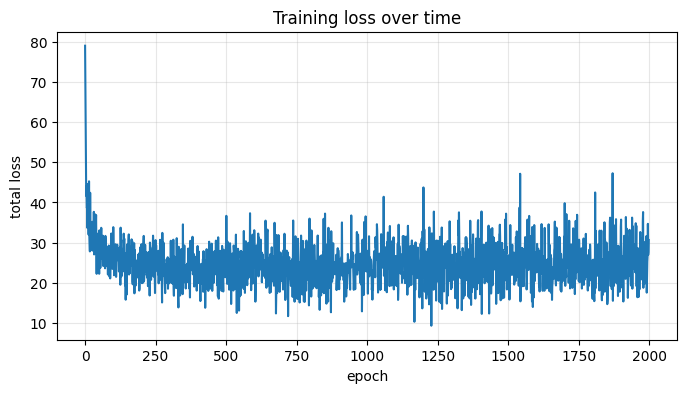

In [12]:
epochs = 2000
lr = 0.1
neg_per_pos = 2  # without negatives, all words just collapse to a single direction
losses = []

for epoch in range(epochs):
    total = 0.0
    for k in rng.permutation(len(positives)):
        # positive pair: y = 1, pull together
        a, b = positives[k]
        ia, ib = w2i[a], w2i[b]
        va, vb = E[ia].copy(), E[ib].copy()  # snapshot before updating
        z = float(np.dot(va, vb))
        yhat = sigmoid(z)
        total += -np.log(yhat + 1e-12)
        g = yhat - 1.0
        E[ia] = va - lr * g * vb
        E[ib] = vb - lr * g * va

        # negative pairs: y = 0, push apart
        for _ in range(neg_per_pos):
            na, nb = neg_sample()
            ina, inb = w2i[na], w2i[nb]
            vna, vnb = E[ina].copy(), E[inb].copy()
            zn = float(np.dot(vna, vnb))
            yhn = sigmoid(zn)
            total += -np.log(1.0 - yhn + 1e-12)
            gn = yhn - 0.0
            E[ina] = vna - lr * gn * vnb
            E[inb] = vnb - lr * gn * vna
    losses.append(total)

print('final loss:', losses[-1])

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('epoch'); plt.ylabel('total loss')
plt.title('Training loss over time')
plt.grid(alpha=0.3)
plt.show()

Trained embeddings:
  bird [-11.49046072   4.66240406]
  cat [-1.33702866 11.65187134]
  chases [-0.06151307  1.48168756]
  dog [ 4.54754528 10.25907359]
  flies [-13.9503297   -3.64318047]
  learns [ 0.54144018 -0.86479394]
  runs [0.53941013 0.42209549]
  sleeps [0.11369436 1.06490463]
  student [  3.52597671 -11.6932173 ]
  studies [ 0.43725403 -0.33194453]
  teacher [ 0.78139239 -1.29347969]
  teaches [ 0.67370165 -1.43699346]


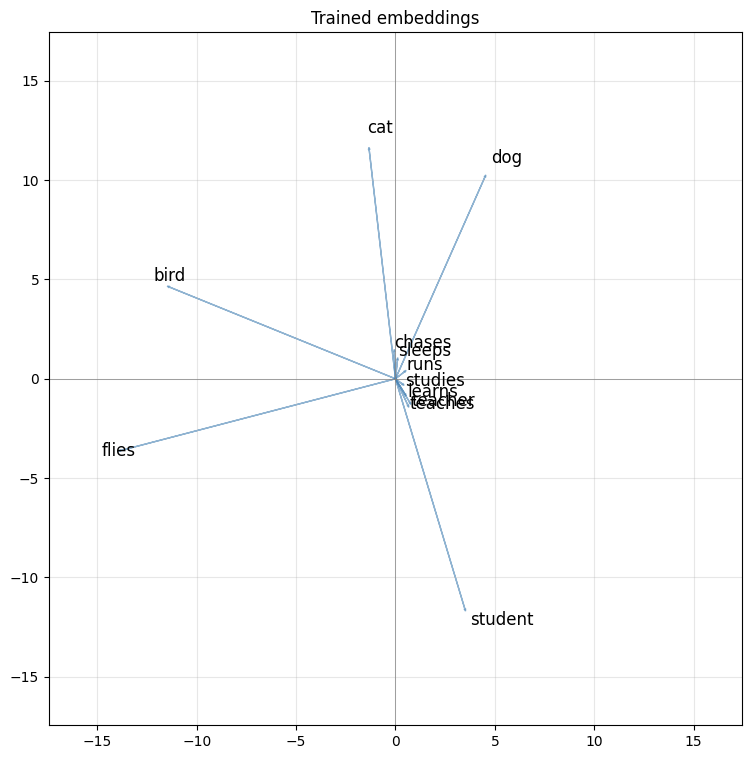

In [13]:
print('Trained embeddings:')
for w in vocab:
    print(' ', w, E[w2i[w]])

fig, ax = plt.subplots(figsize=(9, 9))
for w in vocab:
    v = E[w2i[w]]
    ax.arrow(0, 0, v[0], v[1], head_width=0.08, length_includes_head=True,
             color='steelblue', alpha=0.6)
    ax.text(v[0]*1.06, v[1]*1.06, w, fontsize=12)
mx = float(np.max(np.abs(E))) * 1.25
ax.set_xlim(-mx, mx); ax.set_ylim(-mx, mx)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.set_title('Trained embeddings')
ax.grid(alpha=0.3)
plt.show()

In [14]:
# cosine similarities, sorted to spot the clusters
rows = []
for i, w1 in enumerate(vocab):
    for w2 in vocab[i+1:]:
        rows.append((w1, w2, cos_sim(E[w2i[w1]], E[w2i[w2]])))
rows.sort(key=lambda r: -r[2])
print('Most similar after training:')
for w1, w2, c in rows[:8]:
    print(f'  {w1:9s} ~ {w2:9s}: {c:+.3f}')
print('Most opposite after training:')
for w1, w2, c in rows[-8:]:
    print(f'  {w1:9s} ~ {w2:9s}: {c:+.3f}')

Most similar after training:
  learns    ~ teacher  : +1.000
  cat       ~ chases   : +0.997
  teacher   ~ teaches  : +0.994
  learns    ~ teaches  : +0.993
  student   ~ teaches  : +0.989
  chases    ~ sleeps   : +0.989
  cat       ~ sleeps   : +0.976
  student   ~ teacher  : +0.969
Most opposite after training:
  cat       ~ teacher  : -0.909
  flies     ~ runs     : -0.918
  sleeps    ~ student  : -0.921
  chases    ~ teaches  : -0.922
  cat       ~ teaches  : -0.948
  bird      ~ studies  : -0.965
  chases    ~ student  : -0.969
  cat       ~ student  : -0.984
